#### user_id：用户ID
#### order_dt：购买日期
#### order_products：购买产品数量
#### order_amount：购买金额
#### 数据时间：1997年1月~1998年6月用户行为数据，约6万条

In [58]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
%matplotlib inline
plt.style.use('ggplot')  #更改绘图风格，R语言绘图库风格
plt.rcParams['font.sans-serif'] = ['SimHei']

In [59]:
# 导入数据
columns = ['user_id', 'order_dt', 'order_products', 'order_amount']
df = pd.read_table('CDNOW_master.txt', names=columns, sep=r'\s+')  # sep'\s+'匹配任意个字符
df.head()
# 1.日期格式需要转换
# 2.存在回购/复购行为

,user_id,order_dt,order_products,order_amount
0,1,19970101,1,11.77
1,2,19970112,1,12.00
2,2,19970112,5,77.00
3,3,19970102,2,20.76
4,3,19970330,2,20.76


In [60]:
df.describe()
# 1.用户平均每笔订单购买2.4个商品，标准差2.3，稍微有点波动，属于正常
# 2.75%分位数的数值说明绝大多数订单的购买量都不多，围绕在2~3左右
# 3.购买金额反应出大部分订单集中在中小额30~45左右

,user_id,order_dt,order_products,order_amount
count,69659.000000,6.965900e+04,69659.000000,69659.000000
mean,11470.854592,1.997228e+07,2.410040,35.893648
std,6819.904848,3.837735e+03,2.333924,36.281942
min,1.000000,1.997010e+07,1.000000,0.000000
25%,5506.000000,1.997022e+07,1.000000,14.490000
50%,11410.000000,1.997042e+07,2.000000,25.980000
75%,17273.000000,1.997111e+07,3.000000,43.700000
max,23570.000000,1.998063e+07,99.000000,1286.010000


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69659 entries, 0 to 69658
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         69659 non-null  int64  
 1   order_dt        69659 non-null  int64  
 2   order_products  69659 non-null  int64  
 3   order_amount    69659 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 2.1 MB


### 数据预处理

In [62]:
df['order_date'] = pd.to_datetime(df['order_dt'],format='%Y%m%d')
# format参数：按照指定的格式去匹配要转换的数据列
df['month'] = df['order_date'].dt.to_period('M') #将order_date转化成精度为月份的数据列
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69659 entries, 0 to 69658
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         69659 non-null  int64         
 1   order_dt        69659 non-null  int64         
 2   order_products  69659 non-null  int64         
 3   order_amount    69659 non-null  float64       
 4   order_date      69659 non-null  datetime64[ns]
 5   month           69659 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int64(3), period[M](1)
memory usage: 3.2 MB


### 用户整体消费趋势分析：按月份统计产品购买数量，消费金额，消费次数，消费人数

Text(0.5, 1.0, '每月的消费人数')

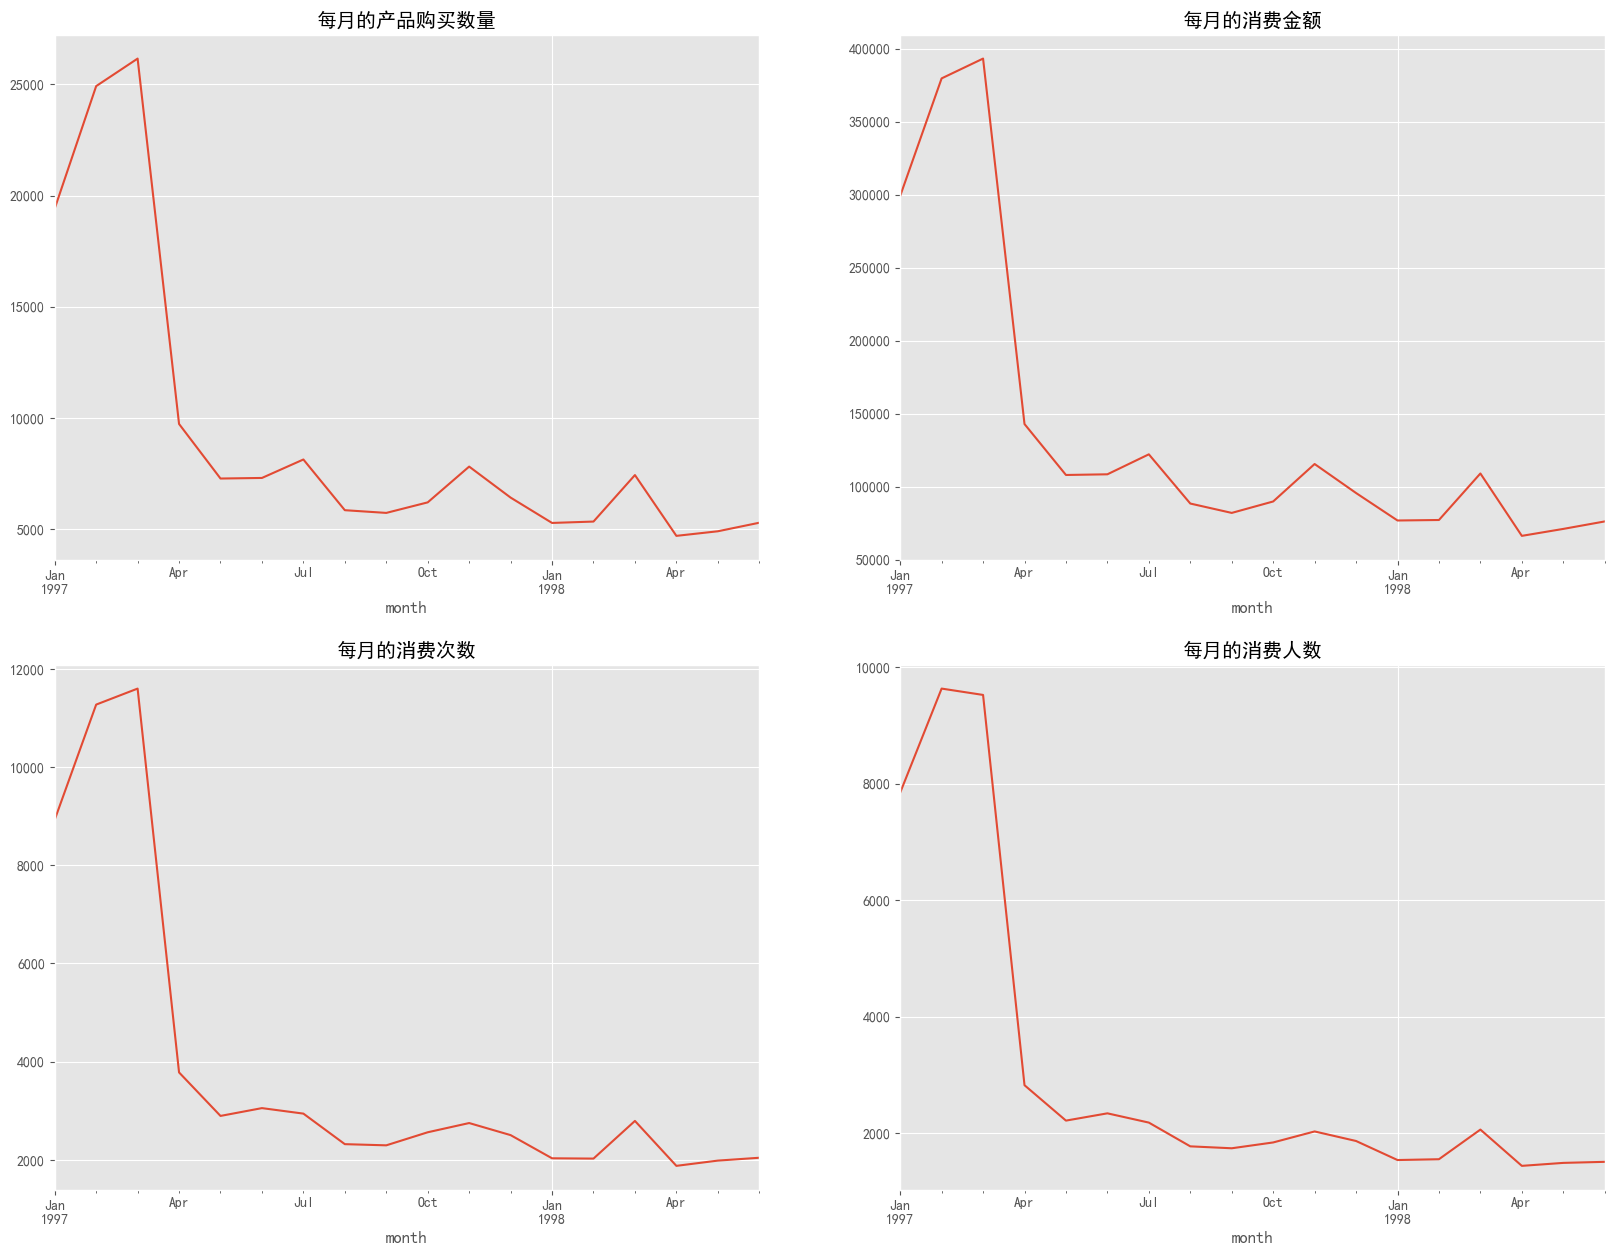

In [63]:
plt.figure(figsize=(20,15))

# 每月的产品购买数量
plt.subplot(221)
df.groupby(by='month')['order_products'].sum().plot()
plt.title('每月的产品购买数量')

# 每月的消费金额
plt.subplot(222)
df.groupby(by='month')['order_amount'].sum().plot()
plt.title('每月的消费金额')

# 每月的消费次数
plt.subplot(223)
df.groupby(by='month')['user_id'].count().plot()
plt.title('每月的消费次数')

# 每月的消费人数（根据user_id进行去重统计）
plt.subplot(224)
df.groupby(by='month')['user_id'].nunique().plot()
plt.title('每月的消费人数')

# 图一：前三个月销量很高，而后销量趋于稳定，并且整体稍微呈现下降趋势
# 图二：前三个月消费金额很高，与消费数量成正比例关系，而后下降严重，可能跟前期投入营销力度较大有关
# 图三：前三个月订单数在10000左右，后续月份的平均消费单数在2500左右
# 图四：前三个月在8000~10000左右，后续不到2000
# 综合：所有数据显示，97年前三月消费事态异常，后续趋于常态化

### 用户个体消费分析
#### 1.用户消费金额，消费次数（产品数量）描述统计

In [64]:
user_grouped = df.groupby(by='user_id').sum(numeric_only=True)
print(user_grouped.describe())
print('用户数量：',len(user_grouped))
# 从用户的角度：每个用户平均购买7个cd，但是中位数是3，典型的右偏分布，存在大量购买的用户，消费金额同理，平均消费与75%分位数几乎相等，存在高额消费的用户

           order_dt  order_products  order_amount
count  2.357000e+04    23570.000000  23570.000000
mean   5.902627e+07        7.122656    106.080426
std    9.460684e+07       16.983531    240.925195
min    1.997010e+07        1.000000      0.000000
25%    1.997021e+07        1.000000     19.970000
50%    1.997032e+07        3.000000     43.395000
75%    5.992125e+07        7.000000    106.475000
max    4.334408e+09     1033.000000  13990.930000
用户数量： 23570


<Axes: xlabel='order_products', ylabel='order_amount'>

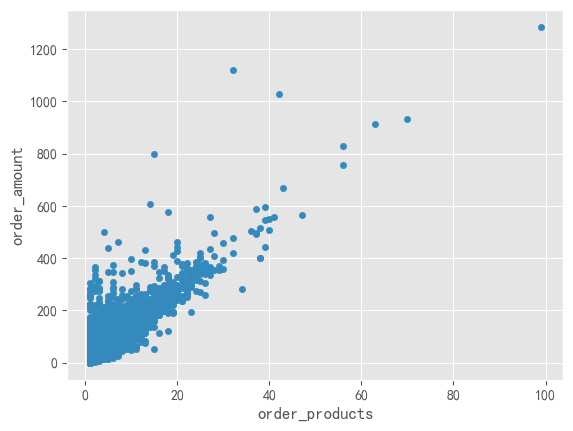

In [65]:
# 绘制每个用户的产品购买量与消费金额的散点图
df.plot(kind='scatter',x='order_products',y='order_amount')
# 消费金额与购买量呈线性趋势
# 订单极值点较少可以忽略不计

#### 2.用户消费分布图

Text(0.5, 0, '每个uid购买的数量')

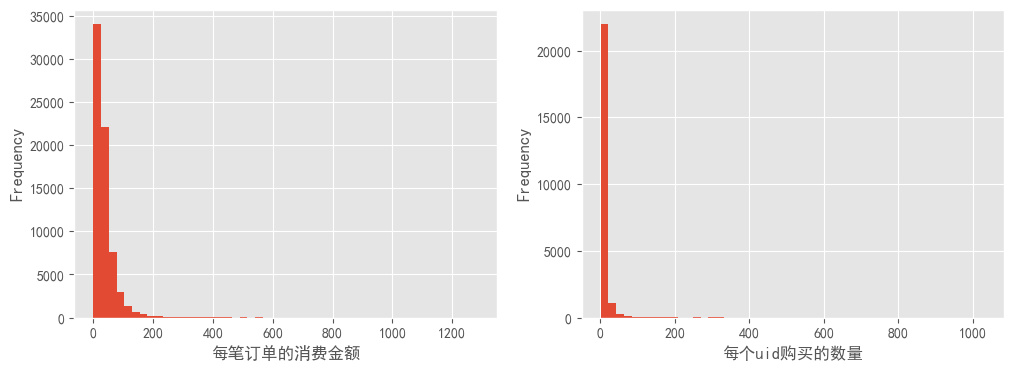

In [66]:
plt.figure(figsize=(12,4))
plt.subplot(121)
df['order_amount'].plot(kind='hist',bins=50)
plt.xlabel('每笔订单的消费金额')
# 图一：消费金额在100以内的订单占据了绝大多数

plt.subplot(122)
df.groupby(by='user_id')['order_products'].sum().plot(kind='hist',bins=50)
plt.xlabel('每个uid购买的数量')
# 图二：每个用户购买量非常小，集中在50以内
# 综合：用户购买量小消费金额低，属于正常现象

#### 3.用户累计消费金额占比分析（用户贡献度）

In [67]:
# 进行用户分组，取出消费金额，进行求和，排序，重置索引
user_cumsum = df.groupby(by='user_id')['order_amount'].sum().sort_values().reset_index()
user_cumsum

,user_id,order_amount
0,10175,0.00
1,4559,0.00
2,1948,0.00
3,925,0.00
4,10798,0.00
...,...,...
23565,7931,6497.18
23566,19339,6552.70
23567,7983,6973.07
23568,14048,8976.33


In [68]:
# 每个用户消费金额累加
user_cumsum['amount_cumsum'] = user_cumsum['order_amount'].cumsum()
user_cumsum.tail()

,user_id,order_amount,amount_cumsum
23565,7931,6497.18,2463822.60
23566,19339,6552.70,2470375.30
23567,7983,6973.07,2477348.37
23568,14048,8976.33,2486324.70
23569,7592,13990.93,2500315.63


In [69]:
amount_total = user_cumsum['amount_cumsum'].max() #消费金额总值
user_cumsum['prop'] = user_cumsum.apply(lambda x:x['amount_cumsum']/amount_total,axis=1) #用户贡献率
user_cumsum.tail()

,user_id,order_amount,amount_cumsum,prop
23565,7931,6497.18,2463822.60,0.985405
23566,19339,6552.70,2470375.30,0.988025
23567,7983,6973.07,2477348.37,0.990814
23568,14048,8976.33,2486324.70,0.994404
23569,7592,13990.93,2500315.63,1.000000


<Axes: >

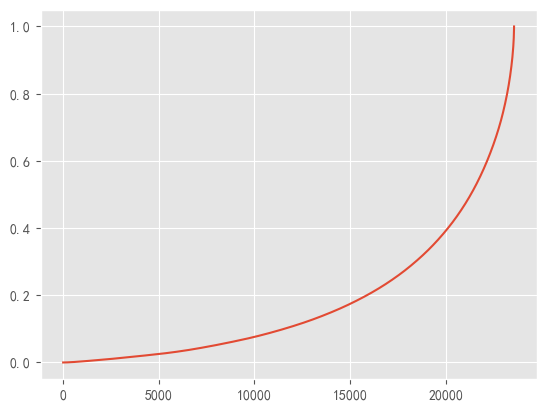

In [70]:
user_cumsum['prop'].plot()
# 前20000名用户贡献总金额的40%，剩余3500名用户贡献了60%（二八法则）

### 用户消费行为
#### 1.首购时间

<Axes: xlabel='order_date'>

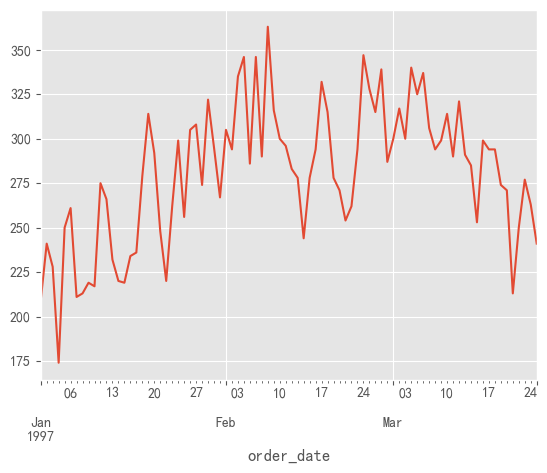

In [71]:
df.groupby(by='user_id')['order_date'].min().value_counts().sort_index().plot()
# 由图可知：首次购买用户在1月1号~2月10号呈明显上升趋势，后续开始逐步下降，可能与公司营销力度相关

#### 2.为最后一次购买时间

<Axes: xlabel='order_date'>

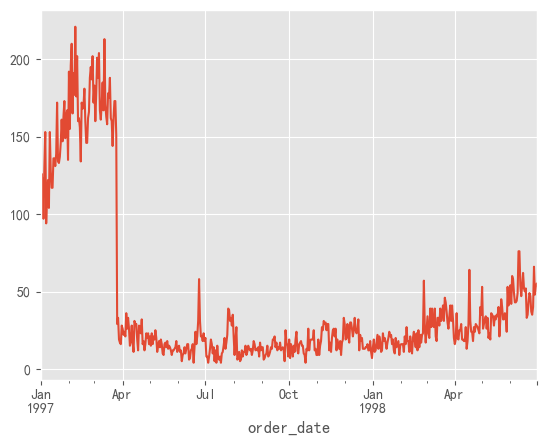

In [72]:
df.groupby(by='user_id')['order_date'].max().value_counts().sort_index().plot()
# 大多数用户最后一次购买时间集中在前3个月，缺少忠诚客户，随着时间推移，流失客户数在整体上升

### 用户分层
#### 1.构建RFM模型

In [73]:
# 透视表的使用
rfm = df.pivot_table(index='user_id',
                     values=['order_products','order_amount','order_date'],
                    aggfunc={
                        'order_date':'max',
                        'order_products':'sum',
                        'order_amount':'sum'
                    })
rfm.head()

,order_amount,order_date,order_products
user_id,,,
1,11.77,1997-01-01,1
2,89.00,1997-01-12,6
3,156.46,1998-05-28,16
4,100.50,1997-12-12,7
5,385.61,1998-01-03,29


In [74]:
rfm['R'] = (rfm['order_date'].max()-rfm['order_date'])/np.timedelta64(1,'D')
rfm.rename(columns={'order_products':'F','order_amount':'M'},inplace=True)
rfm.head()

,M,order_date,F,R
user_id,,,,
1,11.77,1997-01-01,1,545.0
2,89.00,1997-01-12,6,534.0
3,156.46,1998-05-28,16,33.0
4,100.50,1997-12-12,7,200.0
5,385.61,1998-01-03,29,178.0


In [75]:
def rfm_func(x):
    level = x.apply(lambda x:'1' if x>=1 else '0')
    label = level['R'] + level['F'] + level['M']
    d = {
        '111':'重要价值客户',
        '011':'重要保持客户',
        '101':'重要发展客户',
        '001':'重要挽留客户',
        '110':'一般价值客户',
        '010':'一般保持客户',
        '100':'一般发展客户',
        '000':'一般挽留客户'
    }
    result = d[label]
    return result
rfm['label'] = rfm[['R','F','M']].apply(lambda x:x-x.mean()).apply(rfm_func,axis=1)
rfm.head()

,M,order_date,F,R,label
user_id,,,,,
1,11.77,1997-01-01,1,545.0,一般发展客户
2,89.00,1997-01-12,6,534.0,一般发展客户
3,156.46,1998-05-28,16,33.0,重要保持客户
4,100.50,1997-12-12,7,200.0,一般挽留客户
5,385.61,1998-01-03,29,178.0,重要保持客户


Text(0, 0.5, 'R')

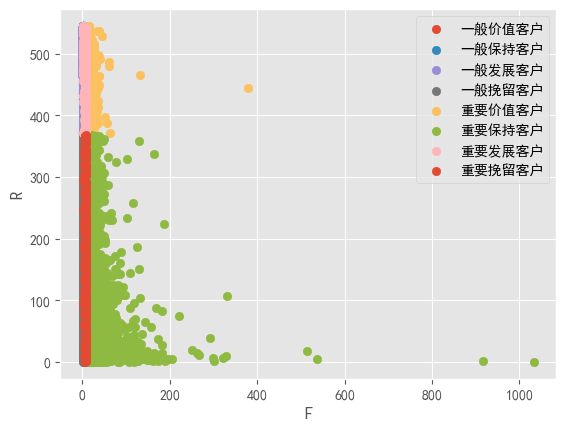

In [76]:
# 客户分层可视化
for label,grouped in rfm.groupby(by='label'):
    x = grouped['F']
    y = grouped['R']
    plt.scatter(x,y,label=label)
plt.legend()
plt.xlabel('F')
plt.ylabel('R')

### 新老、活跃、回流用户分析

In [77]:
pivoted_counts = df.pivot_table(
    index='user_id',
    columns='month',
    values='order_dt',
    aggfunc='count'
).fillna(0)
pivoted_counts

month,1997-01,1997-02,1997-03,1997-04,1997-05,1997-06,1997-07,1997-08,1997-09,1997-10,1997-11,1997-12,1998-01,1998-02,1998-03,1998-04,1998-05,1998-06
user_id,,,,,,,,,,,,,,,,,,
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23566,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23567,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23568,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [78]:
# 直观表格
df_purchase = pivoted_counts.applymap(lambda x:1 if x>0 else 0)
df_purchase.head()

C:\Users\GJ921\AppData\Local\Temp\ipykernel_7680\1320320325.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_purchase = pivoted_counts.applymap(lambda x:1 if x>0 else 0)


month,1997-01,1997-02,1997-03,1997-04,1997-05,1997-06,1997-07,1997-08,1997-09,1997-10,1997-11,1997-12,1998-01,1998-02,1998-03,1998-04,1998-05,1998-06
user_id,,,,,,,,,,,,,,,,,,
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0
4,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
5,1,1,0,1,1,1,1,0,1,0,0,1,1,0,0,0,0,0


In [79]:
# 判断是否为新用户、活跃用户、不活跃用户、回流用户
def active_status(data):
    status = []  # 存储18个月的状态：unreg/new/active/unactive/return
    for i in range(18):
        if data[i] == 0:
            if len(status) == 0:
                status.append('unreg')
            else:
                if status[i-1] == 'unreg':
                    status.append('unreg')
                else:
                    status.append('unactive')
        else:
            if len(status) == 0:
                status.append('new')
            else:
                if status[i-1] == 'unactive':
                    status.append('return')
                elif status[i-1] == 'unreg':
                    status.append('new')
                else:
                    status.append('active')
    return pd.Series(status, df_purchase.columns)
purchase_states = df_purchase.apply(active_status,axis=1)
purchase_states.head()

C:\Users\GJ921\AppData\Local\Temp\ipykernel_7680\3394896769.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data[i] == 0:


month,1997-01,1997-02,1997-03,1997-04,1997-05,1997-06,1997-07,1997-08,1997-09,1997-10,1997-11,1997-12,1998-01,1998-02,1998-03,1998-04,1998-05,1998-06
user_id,,,,,,,,,,,,,,,,,,
1,new,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive
2,new,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive
3,new,unactive,return,active,unactive,unactive,unactive,unactive,unactive,unactive,return,unactive,unactive,unactive,unactive,unactive,return,unactive
4,new,unactive,unactive,unactive,unactive,unactive,unactive,return,unactive,unactive,unactive,return,unactive,unactive,unactive,unactive,unactive,unactive
5,new,active,unactive,return,active,active,active,unactive,return,unactive,unactive,return,active,unactive,unactive,unactive,unactive,unactive


In [80]:
# 用NAN替换unreg
purchase_states_ct = purchase_states.replace('unreg', np.NaN).apply(lambda x: pd.value_counts(x))
purchase_states_ct

C:\Users\GJ921\AppData\Local\Temp\ipykernel_7680\1461405791.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  purchase_states_ct = purchase_states.replace('unreg', np.NaN).apply(lambda x: pd.value_counts(x))
C:\Users\GJ921\AppData\Local\Temp\ipykernel_7680\1461405791.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  purchase_states_ct = purchase_states.replace('unreg', np.NaN).apply(lambda x: pd.value_counts(x))
C:\Users\GJ921\AppData\Local\Temp\ipykernel_7680\1461405791.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  purchase_states_ct = purchase_states.replace('unreg', np.NaN).apply(lambda x: pd.value_counts(x))
C:\Users\GJ921\AppData\Local\Temp\ipykernel_7680\1461405791.py:2: FutureWarning: pandas.value_counts is

month,1997-01,1997-02,1997-03,1997-04,1997-05,1997-06,1997-07,1997-08,1997-09,1997-10,1997-11,1997-12,1998-01,1998-02,1998-03,1998-04,1998-05,1998-06
active,NaN,1157.0,1681,1773.0,852.0,747.0,746.0,604.0,528.0,532.0,624.0,632.0,512.0,472.0,571.0,518.0,459.0,446.0
new,7846.0,8476.0,7248,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
return,NaN,NaN,595,1049.0,1362.0,1592.0,1434.0,1168.0,1211.0,1307.0,1404.0,1232.0,1025.0,1079.0,1489.0,919.0,1029.0,1060.0
unactive,NaN,6689.0,14046,20748.0,21356.0,21231.0,21390.0,21798.0,21831.0,21731.0,21542.0,21706.0,22033.0,22019.0,21510.0,22133.0,22082.0,22064.0


<Axes: xlabel='month'>

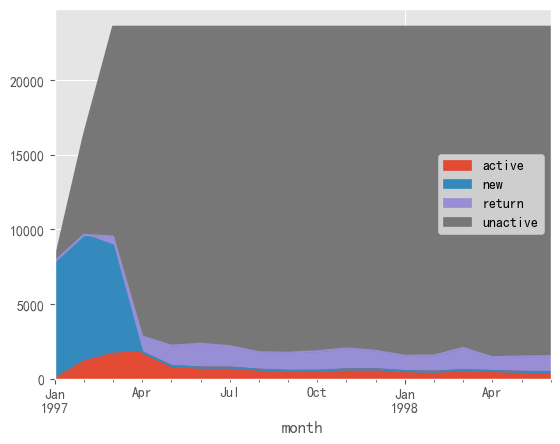

In [81]:
purchase_states_ct.T.fillna(0).plot.area()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, '1997-01'),
  Text(1, 0, '1997-02'),
  Text(2, 0, '1997-03'),
  Text(3, 0, '1997-04'),
  Text(4, 0, '1997-05'),
  Text(5, 0, '1997-06'),
  Text(6, 0, '1997-07'),
  Text(7, 0, '1997-08'),
  Text(8, 0, '1997-09'),
  Text(9, 0, '1997-10'),
  Text(10, 0, '1997-11'),
  Text(11, 0, '1997-12'),
  Text(12, 0, '1998-01'),
  Text(13, 0, '1998-02'),
  Text(14, 0, '1998-03'),
  Text(15, 0, '1998-04'),
  Text(16, 0, '1998-05'),
  Text(17, 0, '1998-06')])

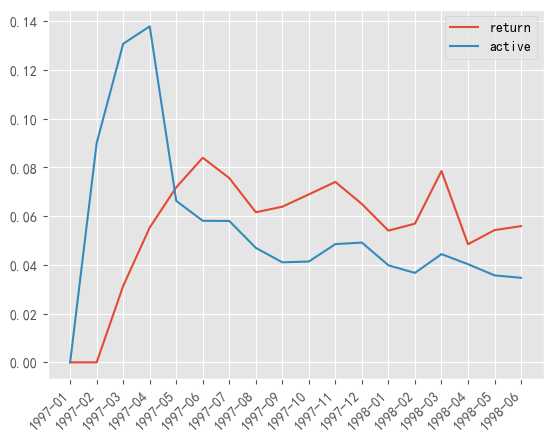

In [82]:
# 回流用户占比
rate = purchase_states_ct.T.fillna(0).apply(lambda x: x/x.sum(), axis=0)
rate.index = rate.index.astype(str)
plt.plot(rate['return'], label='return')
plt.plot(rate['active'], label='active')
plt.legend()
plt.xticks(rotation=45, ha='right')

In [83]:
# 计算购买周期
order_diff = df.groupby(by='user_id').apply(lambda x:x['order_date']-x['order_date'].shift())
print(order_diff.head())
print(order_diff.describe())

user_id   
1        0       NaT
2        1       NaT
         2    0 days
3        3       NaT
         4   87 days
Name: order_date, dtype: timedelta64[ns]
count                         46089
mean     68 days 23:22:13.567662566
std      91 days 00:47:33.924168893
min                 0 days 00:00:00
25%                10 days 00:00:00
50%                31 days 00:00:00
75%                89 days 00:00:00
max               533 days 00:00:00
Name: order_date, dtype: object


C:\Users\GJ921\AppData\Local\Temp\ipykernel_7680\3867844414.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  order_diff = df.groupby(by='user_id').apply(lambda x:x['order_date']-x['order_date'].shift())


<Axes: >

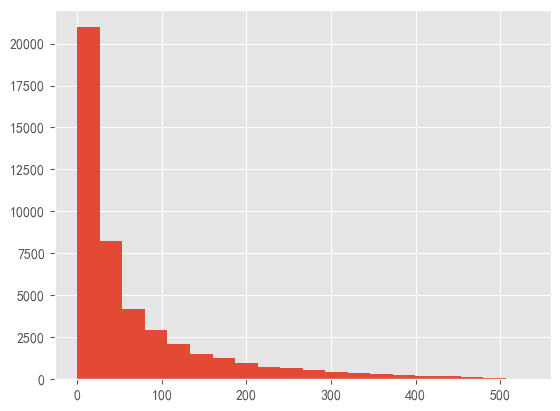

In [84]:
(order_diff/np.timedelta64(1,'D')).hist(bins=20)
# 平均消费周期为68天
# 大多数用户消费周期低于100天
# 呈现典型的长尾分布，只有少部分用户消费周期在200天以上，希望采用措施使其转换成回流用户

### 用户生命周期

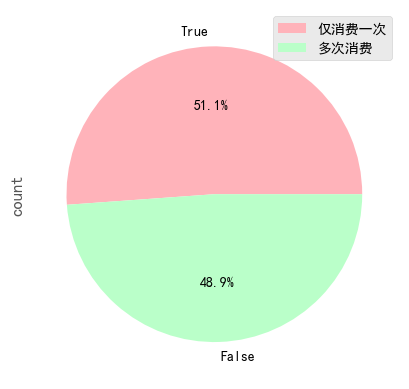

In [88]:
# 计算方式：用户最后一次购买日期-用户第一次购买日期
user_life = df.groupby(by='user_id')['order_date'].agg(['min','max'])
(user_life['max']==user_life['min']).value_counts().plot.pie(autopct='%.1f%%',colors=['#FFB3BA','#BAFFC9'])
plt.legend(['仅消费一次','多次消费'])
# 一半以上用户只消费了一次，留存率不高

In [90]:
# 生命周期分析
(user_life['max']-user_life['min']).describe()
# 用户平均生命周期为134天，但是中位数为0，说明大多数用户只消费了一次，为低质量用户
# 75%分位数以后的用户生命周期>294天，属于核心用户，需要着重维护

count                          23570
mean     134 days 20:55:36.987696224
std      180 days 13:46:43.039788104
min                  0 days 00:00:00
25%                  0 days 00:00:00
50%                  0 days 00:00:00
75%                294 days 00:00:00
max                544 days 00:00:00
dtype: object

Text(0, 0.5, '用户人数')

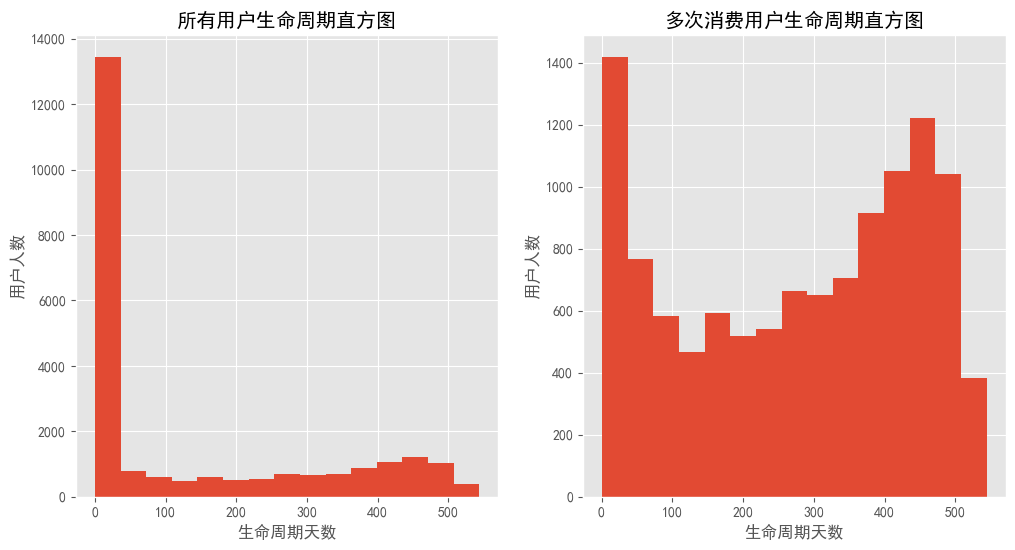

In [95]:
plt.figure(figsize=(12,6))
plt.subplot(121)
((user_life['max']-user_life['min'])/np.timedelta64(1,'D')).hist(bins=15)
plt.title('所有用户生命周期直方图')
plt.xlabel('生命周期天数')
plt.ylabel('用户人数')

plt.subplot(122)
u_1 = (user_life['max']-user_life['min']).reset_index()[0]/np.timedelta64(1,'D')
u_1[u_1>0].hist(bins=15)
plt.title('多次消费用户生命周期直方图')
plt.xlabel('生命周期天数')
plt.ylabel('用户人数')
# 图二可知：过滤掉了低质用户，呈现双峰结构

### 复购率与回购率分析
#### 复购率分析

C:\Users\GJ921\AppData\Local\Temp\ipykernel_7680\3936250990.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  purchase_r = pivoted_counts.applymap(lambda x: 1 if x>1 else np.NaN if x==0 else 0)


<Axes: xlabel='month'>

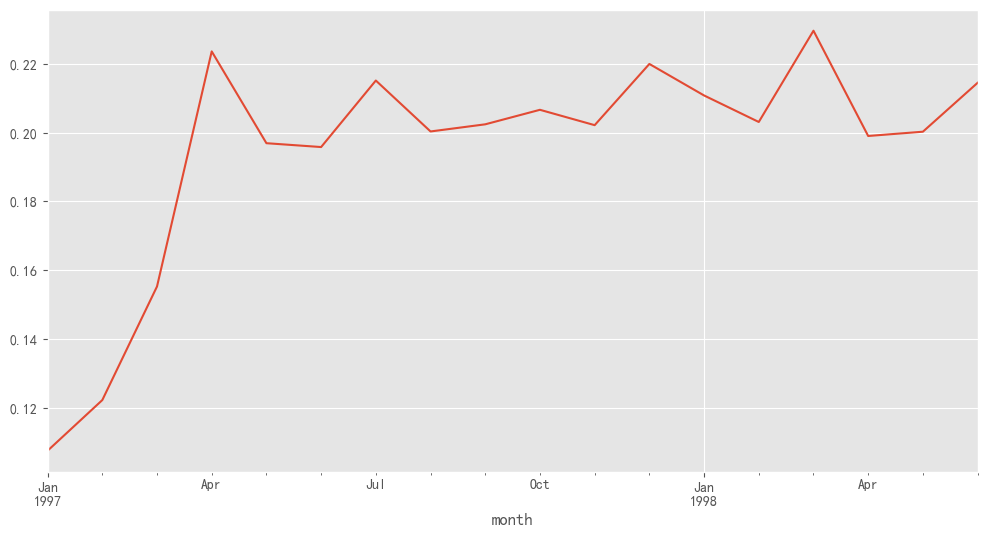

In [96]:
# 计算方式：在自然月内，购买多次的用户在总消费人数中的占比
purchase_r = pivoted_counts.applymap(lambda x: 1 if x>1 else np.NaN if x==0 else 0)
(purchase_r.sum()/purchase_r.count()).plot(figsize=(12,6))

#### 回购率分析

In [98]:
# 计算方式：在一个时间窗口进行了消费，在下一个窗口又进行了消费
def purchase_back(data):
    status = []
    for i in range(17):
        if data[i]==1:
            if data[i+1]==1:
                status.append(1)
            elif data[i+1]==0:
                status.append(0)
        else:
            status.append(np.NaN)
    status.append(np.NaN)
    return pd.Series(status,df_purchase.columns)

purchase_b = df_purchase.apply(purchase_back,axis=1)
purchase_b.head()

C:\Users\GJ921\AppData\Local\Temp\ipykernel_7680\1580463734.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data[i]==1:
C:\Users\GJ921\AppData\Local\Temp\ipykernel_7680\1580463734.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data[i+1]==1:
C:\Users\GJ921\AppData\Local\Temp\ipykernel_7680\1580463734.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif data[i+1]==0:


month,1997-01,1997-02,1997-03,1997-04,1997-05,1997-06,1997-07,1997-08,1997-09,1997-10,1997-11,1997-12,1998-01,1998-02,1998-03,1998-04,1998-05,1998-06
user_id,,,,,,,,,,,,,,,,,,
1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN
4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
5,1.0,0.0,NaN,1.0,1.0,1.0,0.0,NaN,0.0,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN


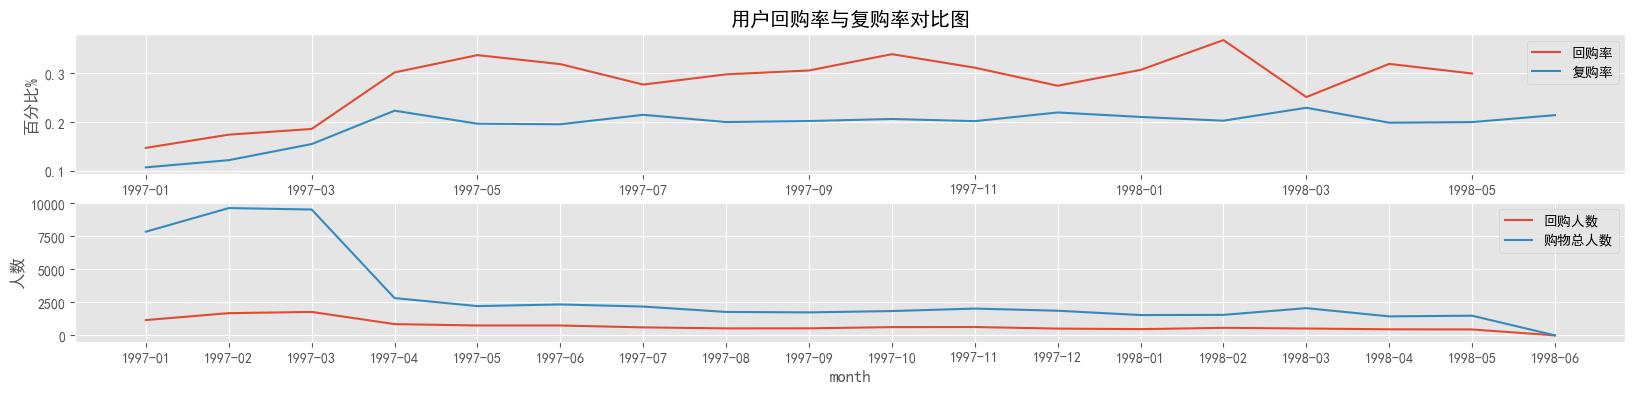

In [102]:
purchase_b.columns = purchase_b.columns.astype(str)
purchase_r.columns = purchase_r.columns.astype(str)
plt.figure(figsize=(20,4))
plt.subplot(211)
(purchase_b.sum()/purchase_b.count()).plot(label='回购率')
(purchase_r.sum()/purchase_r.count()).plot(label='复购率')
plt.legend()
plt.ylabel('百分比%')
plt.title('用户回购率与复购率对比图')

plt.subplot(212)
plt.plot(purchase_b.sum(),label='回购人数')
plt.plot(purchase_b.count(),label='购物总人数')
plt.xlabel('month')
plt.ylabel('人数')
plt.legend()